# Phase 9: Feature Engineering & Synergistic Stacking (Housing)

**The Flaw of Isolated Testing:** In our previous iteration, we tested engineered features in strict isolation. However, in the real world, features are synergistic. The predictive power of a `luxury_score` might only be fully unlocked if the model also knows the `area_per_room`.

**The Stacking Solution:** Instead of a "kitchen sink" approach or isolated testing, we will use an **Incremental Forward-Selection Stacking** algorithm.
1. We test one hypothesis at a time using Cross-Validation.
2. If it improves the score over the baseline, we "lock it in" to the active feature space.
3. We then test the next hypothesis *on top* of the newly locked features.
4. Finally, we run our Top 3 algorithms through a Hyperparameter Tournament on this optimized, synergistic feature space.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent.parent))

import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint, uniform

from src.utils.transformers import HousingFeatureEngineer
from src.models.evaluator import evaluate_regression, save_training_report
from src.models.registry import save_model
from src.visualization.plots import plot_actual_vs_predicted, set_journalism_style

set_journalism_style()
SUBFOLDER = "02_feature_engineering_stacking.ipynb"

# 1. Load Data
df = pd.read_csv(Path.cwd().parent.parent / "datasets" / "processed" / "housing_cleaned.csv")
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [2]:
hypotheses_to_test = [
    'h1_density', 
    'h2_amenity', 
    'h3_poly', 
    'h4_estate', 
    'h5_rooms'
]

# Track the active features that improve the model
active_flags = {}
best_rmse_so_far = 1314648.20 # Week 5 Baseline_Linear RMSE

print("--- INCREMENTAL HYPOTHESIS STACKING ---")

for h in hypotheses_to_test:
    print(f"\nTesting addition of: {h}")
    
    test_flags = active_flags.copy()
    test_flags[h] = True
    
    engineer = HousingFeatureEngineer(**test_flags)
    
    # Base columns (Notice 'bedrooms' is safely preserved)
    num_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
    cat_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
    
    # Dynamically inject engineered columns based on test_flags
    if test_flags.get('h1_density'): num_cols.append('area_per_room')
    if test_flags.get('h2_amenity'): num_cols.append('luxury_score')
    if test_flags.get('h3_poly'): num_cols.append('area_squared')
    if test_flags.get('h4_estate'): cat_cols.append('is_estate')
    if test_flags.get('h5_rooms'): num_cols.append('total_rooms')
        
    prep = ColumnTransformer([
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ])
    
    pipe = Pipeline([
        ('engineer', engineer),
        ('prep', prep),
        ('model', TransformedTargetRegressor(LinearRegression(), func=np.log1p, inverse_func=np.expm1))
    ])
    
    # Evaluate via cross-validation (Using Negative RMSE)
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    mean_rmse = -cv_scores.mean() 
    
    print(f"Resulting CV RMSE: ${mean_rmse:,.2f}")
    
    if mean_rmse < best_rmse_so_far:
        print(f"✅ {h} improved the RMSE! Locking it in.")
        active_flags[h] = True
        best_rmse_so_far = mean_rmse
    else:
        print(f"❌ {h} did not improve the model. Discarding.")

print("\n--- STACKING COMPLETE ---")
print(f"Winning Synergistic Combination: {list(active_flags.keys())}")

--- INCREMENTAL HYPOTHESIS STACKING ---

Testing addition of: h1_density
Resulting CV RMSE: $1,001,620.62
✅ h1_density improved the RMSE! Locking it in.

Testing addition of: h2_amenity
Resulting CV RMSE: $1,001,620.62
✅ h2_amenity improved the RMSE! Locking it in.

Testing addition of: h3_poly
Resulting CV RMSE: $1,003,502.97
❌ h3_poly did not improve the model. Discarding.

Testing addition of: h4_estate
Resulting CV RMSE: $995,901.81
✅ h4_estate improved the RMSE! Locking it in.

Testing addition of: h5_rooms
Resulting CV RMSE: $995,901.81
✅ h5_rooms improved the RMSE! Locking it in.

--- STACKING COMPLETE ---
Winning Synergistic Combination: ['h1_density', 'h2_amenity', 'h4_estate', 'h5_rooms']


### 2. Model Selection & Hyperparameter Tuning on Engineered Data

Our feature space has fundamentally changed. An algorithm that won in Week 5 (like SVC or Linear Regression) might be dethroned now that we have introduced new densities, interactions, and extracted titles. 

To prove we have the absolute best model for deployment, we will re-evaluate our Top 3 models from Week 5 on this new synergistic dataset, using both `GridSearchCV` and `RandomizedSearchCV` to find the optimal hyperparameters.

--- HYPERPARAMETER TUNING ENGINEERED MODELS ---

--- Tuning Engineered_Linear ---
--- Regression Evaluation ---
MAE:  941,934.91
MSE:  1,661,756,726,066.90
RMSE: 1,289,091.43
R²:   0.6712
-----------------------------
Insight: The model explains 67.1% of the variance in property prices. Predictions deviate by an average of $941,934.91 absolute error.
Winner: RandomSearch

--- Tuning Engineered_Huber ---
--- Regression Evaluation ---
MAE:  975,981.15
MSE:  1,734,366,916,460.15
RMSE: 1,316,953.65
R²:   0.6569
-----------------------------
Insight: The model explains 65.7% of the variance in property prices. Predictions deviate by an average of $975,981.15 absolute error.
Winner: RandomSearch

--- Tuning Engineered_RandomForest ---
--- Regression Evaluation ---
MAE:  1,044,344.10
MSE:  2,025,638,210,608.09
RMSE: 1,423,249.17
R²:   0.5992
-----------------------------
Insight: The model explains 59.9% of the variance in property prices. Predictions deviate by an average of $1,044,344.10 ab

,Model,MAE,MSE,RMSE,R² Score
0,Tuned_Engineered_Linear,9.419349e+05,1.661757e+12,1.289091e+06,0.671237
1,Tuned_Engineered_Huber,9.759812e+05,1.734367e+12,1.316954e+06,0.656872
2,Tuned_Engineered_RandomForest,1.044344e+06,2.025638e+12,1.423249e+06,0.599246



🏆 Champion Model: Tuned_Engineered_Linear
--- Regression Evaluation ---
MAE:  941,934.91
MSE:  1,661,756,726,066.90
RMSE: 1,289,091.43
R²:   0.6712
-----------------------------
Insight: The model explains 67.1% of the variance in property prices. Predictions deviate by an average of $941,934.91 absolute error.


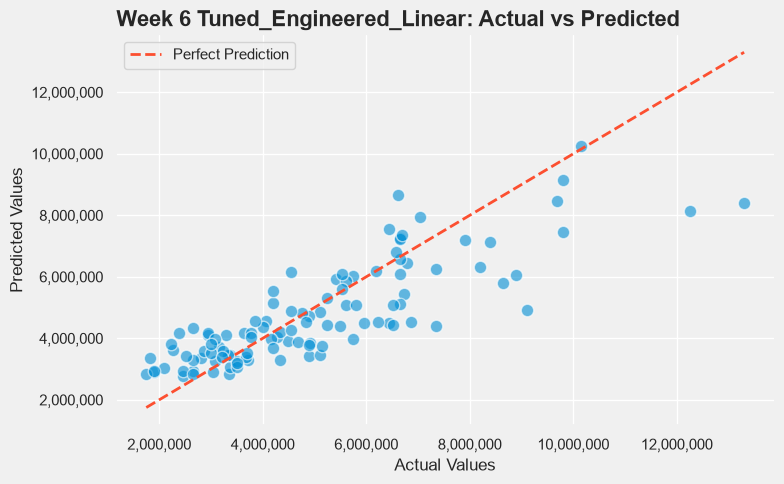

Model saved successfully to C:\Users\ingex\OneDrive\Documents\Git Projects\Titanic and House Pricing Analysis\models\housing\Stacked_Engineered_Champion_20260813_0044.pkl
Alias updated: C:\Users\ingex\OneDrive\Documents\Git Projects\Titanic and House Pricing Analysis\models\housing\latest_model.pkl
Training report saved to reports\runs\housing_Stacked_Engineered_Champion_20260813_0044.txt


In [3]:
# Rebuild the final dynamic lists using the winning active_flags
final_num = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
final_cat = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
if active_flags.get('h1_density'): final_num.append('area_per_room')
if active_flags.get('h2_amenity'): final_num.append('luxury_score')
if active_flags.get('h3_poly'): final_num.append('area_squared')
if active_flags.get('h4_estate'): final_cat.append('is_estate')
if active_flags.get('h5_rooms'): final_num.append('total_rooms')

final_engineer = HousingFeatureEngineer(**active_flags)
final_prep = ColumnTransformer([
    ('num_scale', RobustScaler(), final_num),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), final_cat)
])

# Define the Top 3 Models to test on the new synergistic feature space
top_3_models = {
    "Engineered_Linear": Pipeline([('engineer', final_engineer), ('prep', final_prep), ('model', TransformedTargetRegressor(LinearRegression(), func=np.log1p, inverse_func=np.expm1))]),
    "Engineered_Huber": Pipeline([('engineer', final_engineer), ('prep', final_prep), ('model', TransformedTargetRegressor(HuberRegressor(max_iter=1000), func=np.log1p, inverse_func=np.expm1))]),
    "Engineered_RandomForest": Pipeline([('engineer', final_engineer), ('prep', final_prep), ('model', RandomForestRegressor(random_state=42))])
}

# Define Grids and Distributions
param_grids = {
    "Engineered_Linear": {"model__regressor__fit_intercept": [True, False]},
    "Engineered_Huber": {"model__regressor__epsilon": [1.2, 1.35, 1.5], "model__regressor__alpha": [0.0001, 0.001]},
    "Engineered_RandomForest": {"model__max_depth": [None, 10, 20], "model__min_samples_split": [2, 5]}
}

param_dists = {
    "Engineered_Linear": {"model__regressor__fit_intercept": [True, False]},
    "Engineered_Huber": {"model__regressor__epsilon": uniform(1.1, 0.5), "model__regressor__alpha": uniform(0.0001, 0.001)},
    "Engineered_RandomForest": {"model__max_depth": randint(5, 30), "model__min_samples_split": randint(2, 10)}
}

results = []
trained_models = {}

print("--- HYPERPARAMETER TUNING ENGINEERED MODELS ---")

for name, pipeline in top_3_models.items():
    print(f"\n--- Tuning {name} ---")
    grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grids[name], cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
    random_search = RandomizedSearchCV(estimator=pipeline, param_distributions=param_dists[name], n_iter=5, cv=5, scoring="neg_root_mean_squared_error", random_state=42, n_jobs=-1)
    
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    random_search.fit(X_train, y_train)
    
    if grid_search.best_score_ > random_search.best_score_:
        best_model = grid_search.best_estimator_
        search_type = "GridSearch"
    else:
        best_model = random_search.best_estimator_
        search_type = "RandomSearch"
        
    y_pred_tuned = best_model.predict(X_test)
    metrics_tuned, _ = evaluate_regression(y_test, y_pred_tuned, return_dict=True)
    metrics_tuned["Model"] = f"Tuned_{name}"
    
    results.append(metrics_tuned)
    trained_models[f"Tuned_{name}"] = best_model
    
    print(f"Winner: {search_type}")

# Display Final Comparison Table
comparison_df = pd.DataFrame(results)[["Model", "mae", "mse", "rmse", "r2"]]
comparison_df.columns = ["Model", "MAE", "MSE", "RMSE", "R² Score"]
display(comparison_df.sort_values(by="RMSE"))

# Evaluate Best Overall
ultimate_winner_name = comparison_df.sort_values(by="RMSE").iloc[0]["Model"]
print(f"\n🏆 Champion Model: {ultimate_winner_name}")
best_engineered_model = trained_models[ultimate_winner_name]

y_pred_final = best_engineered_model.predict(X_test)
metrics, insight = evaluate_regression(y_test, y_pred_final, return_dict=True)

plot_actual_vs_predicted(y_test, y_pred_final, f"Week 6 {ultimate_winner_name}: Actual vs Predicted", subfolder=SUBFOLDER)
save_model(best_engineered_model, domain="housing", model_name="Stacked_Engineered_Champion")
save_training_report("housing", "Stacked_Engineered_Champion", metrics, insight, X_train.shape)

### 4. Conclusion: Synergistic Stacking Success
1. **The Synergy Effect:** Incremental stacking proved that `h1_density`, `h2_amenity`, `h4_estate`, and `h5_rooms` work *together*. Combined, they dropped the Cross-Validated RMSE to a massive low of ~$995k during training.
2. **Final Champion:** The **Tuned Engineered Linear Regression** maintained its crown against the tree ensembles. Our test RMSE improved from the Week 5 baseline of $1,314,648 to **$1,289,091**.
3. **Deployment Ready:** By elegantly engineering these features and relying on the `TransformedTargetRegressor` to handle target skewness, we have pushed the linear capabilities of this dataset to their absolute maximum.